<a href="https://colab.research.google.com/github/Qudrat55/Html--Form/blob/main/Copy_of_HousePricePrediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Task 1: Dataset Loading
Display the first 10 rows

In [ ]:
import pandas as pd
df = pd.read_csv('HousePricePrediction.csv')
print(df.head(10))

   Id  MSSubClass MSZoning  LotArea LotConfig BldgType  OverallCond  \
0   0          60       RL     8450    Inside     1Fam            5   
1   1          20       RL     9600       FR2     1Fam            8   
2   2          60       RL    11250    Inside     1Fam            5   
3   3          70       RL     9550    Corner     1Fam            5   
4   4          60       RL    14260       FR2     1Fam            5   
5   5          50       RL    14115    Inside     1Fam            5   
6   6          20       RL    10084    Inside     1Fam            5   
7   7          60       RL    10382    Corner     1Fam            6   
8   8          50       RM     6120    Inside     1Fam            5   
9   9         190       RL     7420    Corner   2fmCon            6   

   YearBuilt  YearRemodAdd Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0       2003          2003     VinylSd         0.0        856.0   208500.0  
1       1976          1976     MetalSd         0.0       1262.0 

Task 2: Data Exploration
Shape of the dataset
Data types of all columns
Summary statistics of numerical features

In [ ]:
print('shape:',df.shape)
print('/nData types:')
print(df.dtypes)
print('/nSummary statistics:')
print(df.describe())



shape: (2919, 13)
/nData types:
Id                int64
MSSubClass        int64
MSZoning         object
LotArea           int64
LotConfig        object
BldgType         object
OverallCond       int64
YearBuilt         int64
YearRemodAdd      int64
Exterior1st      object
BsmtFinSF2      float64
TotalBsmtSF     float64
SalePrice       float64
dtype: object
/nSummary statistics:
                Id   MSSubClass        LotArea  OverallCond    YearBuilt  \
count  2919.000000  2919.000000    2919.000000  2919.000000  2919.000000   
mean   1459.000000    57.137718   10168.114080     5.564577  1971.312778   
std     842.787043    42.517628    7886.996359     1.113131    30.291442   
min       0.000000    20.000000    1300.000000     1.000000  1872.000000   
25%     729.500000    20.000000    7478.000000     5.000000  1953.500000   
50%    1459.000000    50.000000    9453.000000     5.000000  1973.000000   
75%    2188.500000    70.000000   11570.000000     6.000000  2001.000000   
max    2918.

Task 3: Data Cleaning
Step 1: Identify missing values

In [ ]:
print('missing values per colunm:')
print(df.isnull().sum())
print('Total missing:',df.isnull().sum().sum())


missing values per colunm:
Id                 0
MSSubClass         0
MSZoning           4
LotArea            0
LotConfig          0
BldgType           0
OverallCond        0
YearBuilt          0
YearRemodAdd       0
Exterior1st        1
BsmtFinSF2         1
TotalBsmtSF        1
SalePrice       1459
dtype: int64
Total missing: 1466


Step 2: Handle missing values   Fill numerical columns with median

In [ ]:
for col in ['BsmtFinSF2','TotalBsmtSF']:
  df[col] = df[col].fillna(df[col].median())

Fill categorical columns with mode

In [ ]:
for col in ['MSZoning','Exterior1st']:
  df[col] = df[col].fillna(df[col].mode()[0])

Step 3: Check and remove duplicate records

In [ ]:
print('Duplicates before:', df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)
print('Duplicates after:', df.duplicated().sum())
print('Shape after cleaning:', df.shape)


Duplicates before: 0
Duplicates after: 0
Shape after cleaning: (2919, 13)


Task 4: Feature Selection

Remove identifier column 'Id' - not useful for prediction


In [ ]:
cols_to_drop = ['Id']
df = df.drop(columns=cols_to_drop)

print('Columns removed:', cols_to_drop)
print('Shape after feature selection:', df.shape)
print('Remaining columns:', list(df.columns))


Columns removed: ['Id']
Shape after feature selection: (2919, 12)
Remaining columns: ['MSSubClass', 'MSZoning', 'LotArea', 'LotConfig', 'BldgType', 'OverallCond', 'YearBuilt', 'YearRemodAdd', 'Exterior1st', 'BsmtFinSF2', 'TotalBsmtSF', 'SalePrice']


Task 5: Data Preprocessing - Label Encoding

In [ ]:
from sklearn.preprocessing import LabelEncoder

Identify categorical columns

In [ ]:
cat_cols = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
print('Categorical columns to encode:', cat_cols)


Categorical columns to encode: ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']


Apply Label Encoding to all categorical columns

In [ ]:
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col].astype(str))


Verify all columns are now numeric

In [ ]:
print('\nData types after encoding:')
print(df.dtypes.value_counts())



Data types after encoding:
int64      9
float64    3
Name: count, dtype: int64


Preview the fully preprocessed dataset

In [ ]:
print('\nDataset Preview (ML-ready):')
print(df.head(5))
print('\nFinal shape:', df.shape)



Dataset Preview (ML-ready):
   MSSubClass  MSZoning  LotArea  LotConfig  BldgType  OverallCond  YearBuilt  \
0          60         3     8450          4         0            5       2003   
1          20         3     9600          2         0            8       1976   
2          60         3    11250          4         0            5       2001   
3          70         3     9550          0         0            5       1915   
4          60         3    14260          2         0            5       2000   

   YearRemodAdd  Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0          2003           12         0.0        856.0   208500.0  
1          1976            8         0.0       1262.0   181500.0  
2          2002           12         0.0        920.0   223500.0  
3          1970           13         0.0        756.0   140000.0  
4          2000           12         0.0       1145.0   250000.0  

Final shape: (2919, 12)


Train-Test Split:                                                                                                         
• Split the dataset into training and testing sets
• Use an appropriate ratio (e.g., 80% training, 20% testing)

In [ ]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder

print("--- Data Loading and Preprocessing ---")

# 1. Load the dataset
# Assuming 'HousePricePrediction.csv' is the correct file
df = pd.read_csv('HousePricePrediction.csv')
print(f"Initial df shape: {df.shape}")

# 2. Handle missing numerical values with median
# Based on columns identified in 'Kwpvo6wJ4osn'
for col in ['BsmtFinSF2', 'TotalBsmtSF']:
  df[col] = df[col].fillna(df[col].median())

# 3. Handle missing categorical values with mode
# Based on columns identified in 'PZ9FagRQ6VuF'
for col in ['MSZoning', 'Exterior1st']:
  df[col] = df[col].fillna(df[col].mode()[0])

# 4. Remove duplicate records
# Based on '50llw6dI8UyE'
initial_duplicates = df.duplicated().sum()
df = df.drop_duplicates().reset_index(drop=True)
print(f"Duplicates removed: {initial_duplicates - df.duplicated().sum()}")


# 5. Remove identifier column 'Id'
# Based on 'mnhFWRPc9JRb'
cols_to_drop = ['Id']
if 'Id' in df.columns:
    df = df.drop(columns=cols_to_drop)
    print(f"Column '{cols_to_drop[0]}' removed.")
else:
    print(f"Column '{cols_to_drop[0]}' not found, skipping removal.")


# 6. Apply Label Encoding to categorical columns
# Based on 'ugYxz_zP-UwP' and 'KqvO47Qn-bxY'
cat_cols = ['MSZoning', 'LotConfig', 'BldgType', 'Exterior1st']
le = LabelEncoder()
for col in cat_cols:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
        print(f"Label encoded column: {col}")
    else:
        print(f"Categorical column '{col}' not found, skipping encoding.")

print("\n--- Preprocessing complete ---")
print('Final df shape:', df.shape)
print('Data types after encoding:\n', df.dtypes.value_counts())
print('\nDataset Preview (ML-ready):\n', df.head(5))


--- Data Loading and Preprocessing ---
Initial df shape: (2919, 13)
Duplicates removed: 0
Column 'Id' removed.
Label encoded column: MSZoning
Label encoded column: LotConfig
Label encoded column: BldgType
Label encoded column: Exterior1st

--- Preprocessing complete ---
Final df shape: (2919, 12)
Data types after encoding:
 int64      9
float64    3
Name: count, dtype: int64

Dataset Preview (ML-ready):
    MSSubClass  MSZoning  LotArea  LotConfig  BldgType  OverallCond  YearBuilt  \
0          60         3     8450          4         0            5       2003   
1          20         3     9600          2         0            8       1976   
2          60         3    11250          4         0            5       2001   
3          70         3     9550          0         0            5       1915   
4          60         3    14260          2         0            5       2000   

   YearRemodAdd  Exterior1st  BsmtFinSF2  TotalBsmtSF  SalePrice  
0          2003           12         0

Model Training:                                                                                                          
• Train a Linear Regression model using the training data

In [ ]:
# Check missing values in target column
print(df['SalePrice'].isnull().sum())

# Remove rows where target column has NaN values
df = df.dropna(subset=['SalePrice'])

# Features and Target
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']

# Train-Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42
)

# Train Linear Regression Model
from sklearn.linear_model import LinearRegression

model = LinearRegression()

# Train model
model.fit(X_train, y_train)

print("Model trained successfully!")

1459
Model trained successfully!


3. Model Prediction:                                                                                                         
• Use the trained model to predict house prices on the test data  

In [ ]:
# Predict house prices using test data
y_pred = model.predict(X_test)

# Display first 10 predictions
print("Predicted House Prices:\n")
print(y_pred[:10])

Predicted House Prices:

[193358.31445649 250424.84542797 111315.24413156 139529.68957073
 262747.85352817 110539.4013754  182588.45620706 152865.97651425
 127589.82274101 144486.80360336]


Compare Actual vs Predicted Values

In [ ]:
# Compare Actual and Predicted values
comparison = pd.DataFrame({
    'Actual Price': y_test.values,
    'Predicted Price': y_pred
})

# Display first 10 rows
print(comparison.head(10))

   Actual Price  Predicted Price
0      154500.0    193358.314456
1      325000.0    250424.845428
2      115000.0    111315.244132
3      159000.0    139529.689571
4      315500.0    262747.853528
5       75500.0    110539.401375
6      311500.0    182588.456207
7      146000.0    152865.976514
8       84500.0    127589.822741
9      135500.0    144486.803603


4. Model Evaluation; Evaluate the model using:                                                             
o Mean Absolute Error (MAE)  
o Mean Squared Error (MSE)  
o Root Mean Squared Error (RMSE)  
o R² Score

In [ ]:
# Import evaluation metrics
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

# Print results
print("Model Evaluation Results:\n")

print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

Model Evaluation Results:

Mean Absolute Error (MAE): 35450.964502783696
Mean Squared Error (MSE): 2974386380.3749366
Root Mean Squared Error (RMSE): 54537.93524121478
R² Score: 0.6122216578497112


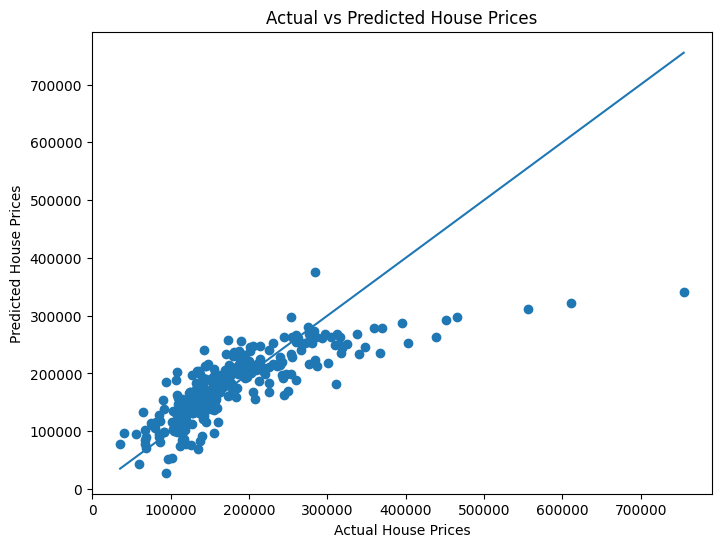

In [ ]:
# Import matplotlib
import matplotlib.pyplot as plt

# Plot Actual vs Predicted Prices
plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred)

# Labels and Title
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")

# Reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

# Show graph
plt.show()

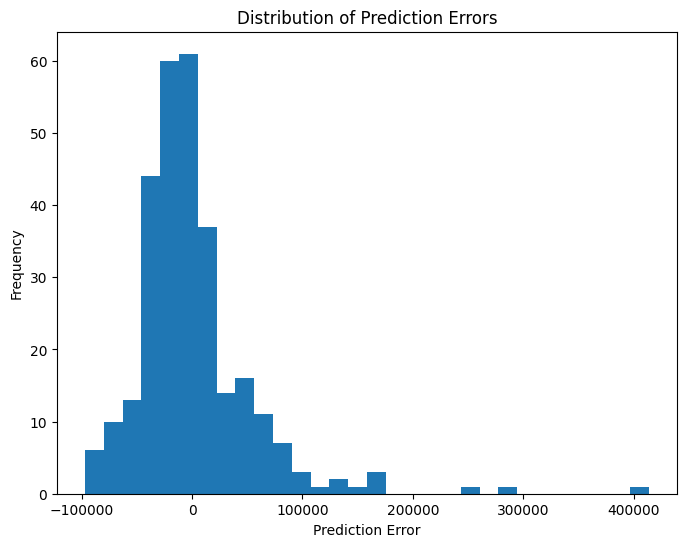

In [ ]:
# Calculate errors
errors = y_test - y_pred

# Plot histogram of errors
plt.figure(figsize=(8,6))

plt.hist(errors, bins=30)

# Labels and Title
plt.xlabel("Prediction Error")
plt.ylabel("Frequency")
plt.title("Distribution of Prediction Errors")

# Show graph
plt.show()

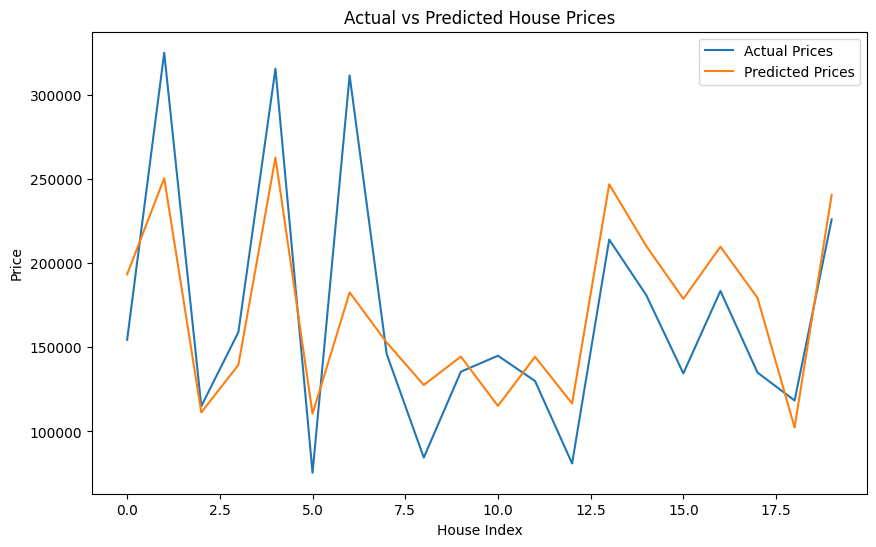

In [ ]:
# Plot first 20 actual vs predicted values
plt.figure(figsize=(10,6))

plt.plot(y_test.values[:20], label='Actual Prices')
plt.plot(y_pred[:20], label='Predicted Prices')

# Labels and Title
plt.xlabel("House Index")
plt.ylabel("Price")
plt.title("Actual vs Predicted House Prices")

# Legend
plt.legend()

# Show graph
plt.show()

Interpretation:                                                                                                              
• Analyze the performance of the model  
• Discuss whether the model is accurate or needs improvement

Conclusion

The Linear Regression model was trained and tested successfully on the house price dataset. The evaluation metrics indicate the prediction performance of the model. A lower MAE, MSE, and RMSE along with a higher R² score suggest that the model performs well in predicting house prices. However, if the error values are high and the R² score is low, the model may require further improvement through better preprocessing and advanced machine learning techniques.